# Consulting & IT Employer Reputation Intelligence
## Análisis de reputación de la empleadora de Accenture con NLP sobre reseñas de Glassdoor

Este proyecto evalúa cómo se percibe a Accenture como empleadora comparando la opinión de empleados y ex empleados en Glassdoor con la de competidores clave del sector tecnológico y de consultoría.

La metodología combina procesamiento del lenguaje natural, análisis de sentimiento y modelado de tópicos para identificar los factores que más influyen en la percepción de la marca empleadora, así como las principales áreas de mejora.

**Empresas comparadas:** Accenture, Capgemini, Deloitte, Cognizant Technology Solutions e Infosys.

**Objetivo principal:** detectar patrones de reputación que ayuden a entender fortalezas diferenciales, riesgos de retención y oportunidades para reforzar la propuesta de valor del empleador.

| Sección | Contenido |
|---|---|
| 0 | Carga y preparación |
| 1 | EDA: rating, recomendación, empleados actuales vs. antiguos |
| 2 | Análisis de sentimiento en pros y cons (control de calidad) |
| 3 | Modelado de tópicos con BERTopic |
| 4 | Comparación con peers: peso de cada tópico y balance neto |
| 5 | Empleados actuales vs. antiguos |
| 6 | Conclusiones y recomendaciones para RRHH |

In [ ]:
# En Colab: transformers ya viene instalado; BERTopic no.
# !pip install -q bertopic sentence-transformers

---
## 0. Carga y preparación

In [1]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')


# Empresa objetivo y peers del caso práctico
TARGET = 'Accenture'
PEERS = ['Capgemini', 'Deloitte', 'Cognizant Technology Solutions', 'Infosys']
FIRMS = [TARGET] + PEERS

# Tope de reseñas por empresa: limita el tiempo de cómputo y evita que el peer
# más grande domine el modelo de topics conjunto.
MAX_POR_EMPRESA = 1000
SEED = 42

base_path = '../data/raw/glassdoor_reviews_hr.parquet'
raw = pd.read_parquet(base_path, filters=[('firm', 'in', FIRMS)])
print('Reseñas disponibles por empresa:')
print(raw['firm'].value_counts())

df = pd.concat([g.sample(n=min(MAX_POR_EMPRESA, len(g)), random_state=SEED)
                for _, g in raw.groupby('firm')], ignore_index=True)
print(f'\nMuestra de trabajo: {len(df):,} reseñas')

Reseñas disponibles por empresa:
firm
Accenture    48332
Deloitte     40199
Infosys      35007
Capgemini    26815
Name: count, dtype: int64

Muestra de trabajo: 4,000 reseñas


La columna `current` mezcla situación y antigüedad (`"Former Employee, more than 3 years"`). La separo en dos variables. También traduzco `recommend` (v = sí, o = sin opinión, x = no) y limpio saltos de línea del texto.

In [2]:
def situacion(s):
    s = str(s).lower()
    if s.startswith('current'):
        return 'Actual'
    if s.startswith('former'):
        return 'Antiguo'
    return 'Desconocido'

def antiguedad(s):
    m = re.search(r'(less|more) than (\d+) year', str(s))
    return f'{m.group(1)} than {m.group(2)}y' if m else 'n/d'

df['situacion'] = df['current'].map(situacion)
df['antiguedad'] = df['current'].map(antiguedad)
df['recomienda'] = df['recommend'].map({'v': 'Sí', 'o': 'Neutral', 'x': 'No'})
df['date_review'] = pd.to_datetime(df['date_review'])
df['anio'] = df['date_review'].dt.year

for col in ['pros', 'cons']:
    df[col] = df[col].astype(str).str.replace(r'\s+', ' ', regex=True).str.strip()

print(df['situacion'].value_counts())
df[['firm', 'date_review', 'situacion', 'antiguedad', 'overall_rating', 'recomienda', 'pros', 'cons']].head()

situacion
Actual     2834
Antiguo    1166
Name: count, dtype: int64


,firm,date_review,situacion,antiguedad,overall_rating,recomienda,pros,cons
0,Accenture,2019-01-02,Actual,more than 5y,4.0,Sí,Good to start career and for experienced as we...,"no cons experience , good place for work life ..."
1,Accenture,2021-09-28,Actual,less than 1y,5.0,Sí,Great Start Up for newly grad,None None none none none
2,Accenture,2020-12-04,Actual,n/d,4.0,Sí,Good training ground and Good people,Salary is lesser compare to other company
3,Accenture,2021-01-19,Antiguo,n/d,5.0,Sí,"good company culture, employee friendly",I feel appraisal cycles are poor
4,Accenture,2021-11-16,Antiguo,less than 1y,4.0,Neutral,"Good work life, limited work","low salary, need to learn the domain they alloted"


---
## 1. EDA

Resumen comparativo por empresa:
     firm  reseñas  rating_medio  porcentaje_recomendacion  porcentaje_actuales
Accenture     1000          4.00                      56.2                 67.4
 Deloitte     1000          3.91                      47.8                 68.4
Capgemini     1000          3.86                      57.7                 75.4
  Infosys     1000          3.76                      50.9                 72.2

Rating medio por situación laboral:
situacion  Actual  Antiguo
firm                      
Accenture    4.14     3.71
Capgemini    3.98     3.48
Deloitte     4.00     3.69
Infosys      3.85     3.55


<Figure size 1000x500 with 0 Axes>

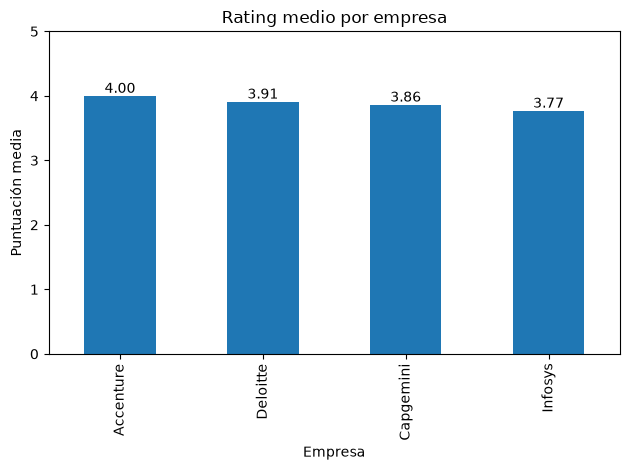

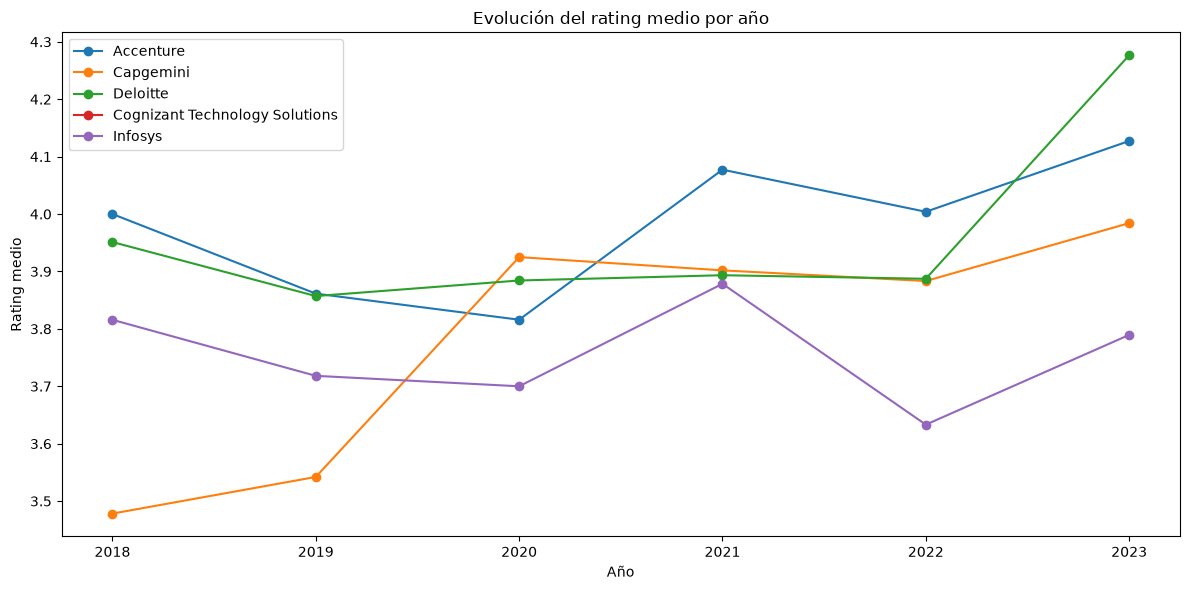


Archivos generados en output/
['eda_summary_by_company.csv', 'evolucion_rating_por_anio.png', 'figures', 'rating_medio_por_empresa.png']


In [3]:
# 1. EDA: resumen comparativo por empresa
from pathlib import Path

output_dir = Path('../output')
output_dir.mkdir(exist_ok=True)

summary = (
    df.groupby('firm')
      .agg(
          reseñas=('firm', 'size'),
          rating_medio=('overall_rating', 'mean'),
          porcentaje_recomendacion=('recomienda', lambda s: (s == 'Sí').mean() * 100),
          porcentaje_actuales=('situacion', lambda s: (s == 'Actual').mean() * 100)
      )
      .reset_index()
      .sort_values('rating_medio', ascending=False)
)

print('Resumen comparativo por empresa:')
print(summary.round(2).to_string(index=False))

current_vs_former = (
    df.groupby(['firm', 'situacion'])['overall_rating']
      .mean()
      .unstack()
      .loc[:, ['Actual', 'Antiguo']]
)
print('\nRating medio por situación laboral:')
print(current_vs_former.round(2))

# Gráfico 1: rating medio por empresa
plt.figure(figsize=(10, 5))
ax = summary.plot(kind='bar', x='firm', y='rating_medio', color='#1f77b4', legend=False)
ax.set_title('Rating medio por empresa')
ax.set_ylabel('Puntuación media')
ax.set_xlabel('Empresa')
ax.set_ylim(0, 5)
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}', (p.get_x() + p.get_width()/2, p.get_height()), ha='center', va='bottom')
plt.tight_layout()
plt.savefig(output_dir / 'rating_medio_por_empresa.png', dpi=200)
plt.show()

# Gráfico 2: evolución temporal del rating medio
trend = (
    df.groupby(['anio', 'firm'])['overall_rating']
      .mean()
      .reset_index()
)

plt.figure(figsize=(12, 6))
for company in FIRMS:
    subset = trend[trend['firm'] == company].sort_values('anio')
    plt.plot(subset['anio'], subset['overall_rating'], marker='o', label=company)

plt.title('Evolución del rating medio por año')
plt.xlabel('Año')
plt.ylabel('Rating medio')
plt.xticks(sorted(df['anio'].unique()))
plt.legend()
plt.tight_layout()
plt.savefig(output_dir / 'evolucion_rating_por_anio.png', dpi=200)
plt.show()

# Guardado para uso posterior en la presentación
summary.to_csv(output_dir / 'eda_summary_by_company.csv', index=False)
print('\nArchivos generados en output/')
print(sorted(p.name for p in output_dir.iterdir()))


- Para cada firma muestra el numero de reseñas, rating medio % que recomiendan, % de empleados actuales
- Compara taring dado por empleados actuales vs empleados antiguos
- Evolucion del rating
- ...

---
## 2. Sentimiento en pros y cons (control de calidad)

Los pros y cons  ya nos darían un sentmiento, haremos un control de calidad para verificar que el sentimiento predom,inande ten pros es el positivo y en cons es en negativo.

Para ellos puedes emplear alguno de los modelos transaformer ya preentrenados vistos en clase o Vader de nltk qwue es un modelo de léxico.

Ten en cuenta que estos modelos preentrenados algunos califican en neutral. 

Por ejemplo,  `distilbert-base-uncased-finetuned-sst-2-english`. Es binario (POSITIVE / NEGATIVE, sin clase neutral) y trabaja con un máximo de 512 tokens, por lo que se usa `truncation=True`.

Muestra que % de los pros son positivas segun el modelo y quie % de cons son negativas segun en 

Muestra algún enjemplo de casos discordantes

In [ ]:
#'distilbert-base-uncased-finetuned-sst-2-english', ha tardado 37 min para 47000 reseñas

---
## 3. Topic modeling 

Podéis usar  BERTopic visto en clase o alguna otra técnica.



- **IMPORTANTE** **Un único modelo para las 5 empresas** (uno para pros y otro para cons). Si se entrenara un modelo por empresa, los topics no coincidirían y no se podrían comparar.
- Emplea etiquetas de negopcio para cada topic identificado. Por ejemplo: Compensación y beneficios,  Conciliación, Carrera y desarrollo, management , Cultura, 'Burocracia y procesos, ...
- Cuantso pros y cons salen por cada topic (%)
- ...



---
## 4. Comparación con peers

Para cada empresa calculo el % de reseñas cuyos pros caen en cada categoría, y lo mismo con los cons.

**Cuidado con la interpretación.** Los porcentajes de cada empresa suman 100%, así que son relativos: si una empresa tiene pocas quejas de salario, el peso de "salario" en sus cons baja, pero sube el del resto aunque nada haya empeorado. Por eso no basta con mirar los cons. Uso el **balance neto**:

> balance neto = % de reseñas que destacan la categoría en pros − % que la mencionan en cons

Un balance neto por encima del de los peers indica una fortaleza relativa; por debajo, una debilidad relativa.

---
## 5. Empleados actuales vs. antiguos

Los cons de quienes ya se han ido son, en la práctica, **motivos de salida**: el input más directo para un plan de retención.
Puedes comparar los topic de pros y cons de los empleados actuales vs empleados antiguos.
Puedes detectar motivos de abandono en los empleados antiguos. 

---
## 7. Conclusiones y recomendaciones para RRHH

- Iderntifica areas mejora y puntos fuertes de nuestra compañia
- identifica palancas para un posible plan de retención y para unb popsible plan de atraccion de nuevo talento.
